In [8]:
%%writefile /kaggle/working/config.py
import torch

# ==========================================================
# Paths
# ==========================================================

PNG_DIR = "/kaggle/input/datasets/hareemzia58/rsna-intracranial-hemorrhage-png-384x384/rsna_dataset_png/rsna_dataset_png"

METADATA_CSV = "/kaggle/input/datasets/hareemzia58/rsna-intracranial-hemorrhage-png-384x384/rsna_metadata.csv"

CHECKPOINT_DIR = "/kaggle/working/checkpoints"

RESULTS_DIR = "/kaggle/working/results"

# ==========================================================
# Data
# ==========================================================

IMG_SIZE = 384

BATCH_SIZE = 16

NUM_WORKERS = 2

PATIENT_ID_COL = "PatientID"

# ==========================================================
# Labels
# ==========================================================

LABEL_COLS = [
    "any",
    "epidural",
    "intraparenchymal",
    "intraventricular",
    "subarachnoid",
    "subdural",
]

NUM_CLASSES = len(LABEL_COLS)

# ==========================================================
# Model
# ==========================================================

MODEL_VARIANT = "efficientnet_b0"

PRETRAINED = True

DROPOUT = 0.3

# ==========================================================
# Optimizer
# ==========================================================

LR = 2e-4

WEIGHT_DECAY = 1e-4

# ==========================================================
# Class-Balanced Focal Loss
# ==========================================================

CB_BETA = 0.9995

FOCAL_GAMMA = 2.0

# ==========================================================
# Training
# ==========================================================

EPOCHS = 50

PATIENCE = 8

USE_AMP = True

SEED = 42

# ==========================================================
# Device
# ==========================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

Overwriting /kaggle/working/config.py


In [9]:
%%writefile /kaggle/working/model.py
import torch.nn as nn
from torchvision import models


_MODEL_REGISTRY = {
    "efficientnet_b0": (
        models.efficientnet_b0,
        models.EfficientNet_B0_Weights.IMAGENET1K_V1,
    )
}


class HemorrhageEfficientNet(nn.Module):

    def __init__(
        self,
        num_classes=6,
        pretrained=True,
        dropout=0.3,
        variant="efficientnet_b0",
    ):

        super().__init__()

        constructor, weights = _MODEL_REGISTRY[variant]

        self.backbone = constructor(
            weights=weights if pretrained else None
        )

        in_features = self.backbone.classifier[1].in_features

        self.backbone.classifier = nn.Sequential(

            nn.Dropout(dropout),

            nn.Linear(
                in_features,
                num_classes,
            ),
        )

    def forward(self, x):

        return self.backbone(x)


def build_model(device=None):

    model = HemorrhageEfficientNet(
        num_classes=6,
        pretrained=True,
        dropout=0.3,
        variant="efficientnet_b0",
    )

    if device is not None:
        model = model.to(device)

    return model

Overwriting /kaggle/working/model.py


In [10]:
%%writefile /kaggle/working/losses.py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


class ClassBalancedFocalLoss(nn.Module):

    def __init__(
        self,
        samples_per_class,
        beta=0.9999,
        gamma=2.0,
        reduction="mean",
    ):

        super().__init__()

        effective_num = 1.0 - np.power(beta, samples_per_class)

        weights = (1.0 - beta) / effective_num

        weights = weights / weights.mean()

        self.register_buffer(
            "class_weights",
            torch.tensor(weights, dtype=torch.float32),
        )

        self.gamma = gamma

        self.reduction = reduction

    def forward(self, logits, targets):

        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none",
        )

        probs = torch.sigmoid(logits)

        pt = probs * targets + (1 - probs) * (1 - targets)

        focal = (1 - pt) ** self.gamma

        weights = self.class_weights.to(logits.device).unsqueeze(0)
        
        loss = weights * focal * bce

        if self.reduction == "mean":
            return loss.mean()

        elif self.reduction == "sum":
            return loss.sum()

        return loss

Overwriting /kaggle/working/losses.py


In [11]:
%%writefile /kaggle/working/data_loader.py
import os
import cv2
import torch
import numpy as np
import pandas as pd

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler,
)

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import StratifiedGroupKFold


# -------------------------------------------------------
# Augmentations
# -------------------------------------------------------

def get_train_transforms(img_size=384):

    return A.Compose([

        A.HorizontalFlip(p=0.5),

        A.Affine(
            translate_percent=(-0.03, 0.03),
            scale=(0.95, 1.05),
            rotate=(-10, 10),
            p=0.5,
        ),

        A.CLAHE(
            clip_limit=(1,4),
            tile_grid_size=(8,8),
            p=0.30,
        ),

        A.RandomGamma(
            gamma_limit=(85,115),
            p=0.30,
        ),

        A.GaussNoise(
            std_range=(0.01,0.03),
            mean_range=(0.0,0.0),
            p=0.20,
        ),

        A.Resize(img_size, img_size),

        A.Normalize(
            mean=[0.485,0.456,0.406],
            std=[0.229,0.224,0.225],
        ),

        ToTensorV2(),

    ])


def get_val_transforms(img_size=384):

    return A.Compose([

        A.Resize(img_size, img_size),

        A.Normalize(
            mean=[0.485,0.456,0.406],
            std=[0.229,0.224,0.225],
        ),

        ToTensorV2(),

    ])


# -------------------------------------------------------
# Dataset
# -------------------------------------------------------

class RSNADataset(Dataset):

    def __init__(self, df, img_dir, transform=None):

        self.df = df.reset_index(drop=True)

        self.img_dir = img_dir

        self.transform = transform

        self.label_cols = [

            "any",

            "epidural",

            "intraparenchymal",

            "intraventricular",

            "subarachnoid",

            "subdural",

        ]

        self.labels = self.df[self.label_cols].values.astype(np.float32)

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        image_id = self.df.iloc[idx]["Image_ID"]

        path = os.path.join(
            self.img_dir,
            image_id + ".png",
        )

        image = cv2.imread(path)

        if image is None:
            raise FileNotFoundError(path)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform is not None:

            image = self.transform(image=image)["image"]

        label = torch.tensor(
            self.labels[idx],
            dtype=torch.float32,
        )

        return image, label


# -------------------------------------------------------
# Weighted sampler
# -------------------------------------------------------

def build_weighted_sampler(train_df):

    label_cols = [

        "any",

        "epidural",

        "intraparenchymal",

        "intraventricular",

        "subarachnoid",

        "subdural",

    ]

    labels = train_df[label_cols].values

    positives = labels.sum(axis=0)
    negatives = len(train_df) - positives

    class_weights = negatives / np.clip(positives, 1, None)
    class_weights = np.sqrt(class_weights)
    class_weights = np.minimum(class_weights, 10)

    sample_weights = np.ones(len(train_df), dtype=np.float32)

    for i in range(len(train_df)):

        positive_classes = np.where(labels[i] == 1)[0]

        if len(positive_classes) > 0:

            sample_weights[i] = class_weights[positive_classes].max()

    print("\nSampler class weights")
    for name, w in zip(label_cols, class_weights):
        print(f"{name:20s}: {w:.2f}")
    print(f"\nSample weight range: {sample_weights.min():.2f} - {sample_weights.max():.2f}")
    print(f"Mean sample weight : {sample_weights.mean():.2f}")
    
    sampler = WeightedRandomSampler(

        weights=torch.as_tensor(sample_weights, dtype=torch.double),

        num_samples=len(sample_weights),

        replacement=True,

    )

    return sampler


# -------------------------------------------------------
# Data loaders
# -------------------------------------------------------

def prepare_dataloaders(

    df,

    img_dir,

    batch_size,

    num_workers,

    img_size,

    patient_col="PatientID",

):

    groups = df[patient_col]

    y = df["any"]

    outer = StratifiedGroupKFold(

        n_splits=5,

        shuffle=True,

        random_state=42,

    )

    train_idx, temp_idx = next(

        outer.split(df, y, groups)

    )

    train_df = df.iloc[train_idx].reset_index(drop=True)

    temp_df = df.iloc[temp_idx].reset_index(drop=True)

    inner = StratifiedGroupKFold(

        n_splits=2,

        shuffle=True,

        random_state=42,

    )

    val_idx, test_idx = next(

        inner.split(

            temp_df,

            temp_df["any"],

            temp_df[patient_col],

        )

    )

    val_df = temp_df.iloc[val_idx].reset_index(drop=True)

    test_df = temp_df.iloc[test_idx].reset_index(drop=True)

    print()

    print("Dataset Summary")

    print("----------------------------")

    print("Train :", len(train_df))

    print("Val   :", len(val_df))

    print("Test  :", len(test_df))

    train_dataset = RSNADataset(

        train_df,

        img_dir,

        get_train_transforms(img_size),

    )

    val_dataset = RSNADataset(

        val_df,

        img_dir,

        get_val_transforms(img_size),

    )

    test_dataset = RSNADataset(

        test_df,

        img_dir,

        get_val_transforms(img_size),

    )

    sampler = build_weighted_sampler(train_df)

    pin = torch.cuda.is_available()

    train_loader = DataLoader(

        train_dataset,

        batch_size=batch_size,

        sampler=sampler,

        shuffle=False,

        num_workers=num_workers,

        pin_memory=pin,

        persistent_workers=(num_workers > 0),

        prefetch_factor=2 if num_workers > 0 else None,

        drop_last=False,

    )

    val_loader = DataLoader(

        val_dataset,

        batch_size=batch_size,

        shuffle=False,

        num_workers=num_workers,

        pin_memory=pin,

        persistent_workers=(num_workers > 0),

        prefetch_factor=2 if num_workers > 0 else None,

    )

    test_loader = DataLoader(

        test_dataset,

        batch_size=batch_size,

        shuffle=False,

        num_workers=num_workers,

        pin_memory=pin,

        persistent_workers=(num_workers > 0),

        prefetch_factor=2 if num_workers > 0 else None,

    )

    samples_per_class = train_df[
        [
            "any",
            "epidural",
            "intraparenchymal",
            "intraventricular",
            "subarachnoid",
            "subdural",
        ]
    ].sum().values.astype(np.int64)

    return (
        train_loader,
        val_loader,
        test_loader,
        samples_per_class,
    )

Overwriting /kaggle/working/data_loader.py


In [12]:
%%writefile /kaggle/working/metrics.py
import numpy as np

from sklearn.metrics import (
    classification_report,
    average_precision_score,
    precision_recall_curve,
    f1_score,
)

LABELS = [
    "any",
    "epidural",
    "intraparenchymal",
    "intraventricular",
    "subarachnoid",
    "subdural",
]


# -------------------------------------------------------
# Apply thresholds
# -------------------------------------------------------

def apply_thresholds(probabilities, thresholds):
    thresholds = np.asarray(thresholds)
    return (probabilities >= thresholds).astype(np.uint8)


# -------------------------------------------------------
# Macro F1
# -------------------------------------------------------

def macro_f1(y_true, y_pred):
    return f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )


# -------------------------------------------------------
# PR-AUC
# -------------------------------------------------------

def compute_pr_auc(y_true, probabilities):

    scores = {}

    for i, label in enumerate(LABELS):

        scores[label] = average_precision_score(
            y_true[:, i],
            probabilities[:, i],
        )

    return scores


# -------------------------------------------------------
# Learn best threshold per class
# -------------------------------------------------------

def find_best_thresholds(y_true, probabilities):

    best_thresholds = []
    best_f1_scores = []

    for i in range(len(LABELS)):

        precision, recall, thresholds = precision_recall_curve(
            y_true[:, i],
            probabilities[:, i],
        )

        # precision_recall_curve returns N+1 precision/recall values
        # but only N thresholds.
        f1 = (
            2 * precision[:-1] * recall[:-1]
        ) / (
            precision[:-1] + recall[:-1] + 1e-12
        )

        best_idx = np.argmax(f1)

        best_thresholds.append(thresholds[best_idx])
        best_f1_scores.append(f1[best_idx])

    return (
        np.array(best_thresholds),
        np.array(best_f1_scores),
    )


# -------------------------------------------------------
# Classification report
# -------------------------------------------------------

def classification_report_from_probs(
    y_true,
    probabilities,
    thresholds,
):

    preds = apply_thresholds(
        probabilities,
        thresholds,
    )

    return classification_report(
        y_true,
        preds,
        target_names=LABELS,
        zero_division=0,
    )


# -------------------------------------------------------
# Complete evaluation
# -------------------------------------------------------

def evaluate(
    y_true,
    probabilities,
):

    # 1. Learn thresholds from validation predictions
    best_thresholds, best_f1 = find_best_thresholds(
        y_true,
        probabilities,
    )

    # 2. Apply learned thresholds
    preds = apply_thresholds(
        probabilities,
        best_thresholds,
    )

    # 3. Compute Macro F1 USING learned thresholds
    macro = macro_f1(
        y_true,
        preds,
    )

    # 4. Classification report
    report = classification_report(
        y_true,
        preds,
        target_names=LABELS,
        zero_division=0,
    )

    # 5. PR-AUC
    pr_auc = compute_pr_auc(
        y_true,
        probabilities,
    )

    return {

        "macro_f1": macro,

        "report": report,

        "pr_auc": pr_auc,

        "best_thresholds": best_thresholds,

        "best_f1": best_f1,

        "predictions": preds,

    }

Overwriting /kaggle/working/metrics.py


In [13]:
%%writefile /kaggle/working/train.py
import os
import random
import numpy as np

import torch
import torch.nn as nn

from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

from torch.amp import autocast, GradScaler

import pandas as pd

from tqdm import tqdm

import config

from model import build_model
from losses import ClassBalancedFocalLoss
from data_loader import prepare_dataloaders
from metrics import evaluate


# -------------------------------------------------------
# Seed
# -------------------------------------------------------

def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(config.SEED)

os.makedirs(config.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(config.RESULTS_DIR, exist_ok=True)


# -------------------------------------------------------
# Data
# -------------------------------------------------------

df = pd.read_csv(config.METADATA_CSV)

train_loader, val_loader, test_loader, samples_per_class = prepare_dataloaders(
    df=df,
    img_dir=config.PNG_DIR,
    batch_size=config.BATCH_SIZE,
    num_workers=config.NUM_WORKERS,
    img_size=config.IMG_SIZE,
    patient_col=config.PATIENT_ID_COL,
)


# -------------------------------------------------------
# Model
# -------------------------------------------------------

model = build_model(config.DEVICE)

criterion = ClassBalancedFocalLoss(
    samples_per_class=samples_per_class,
    beta=config.CB_BETA,
    gamma=config.FOCAL_GAMMA,
).to(config.DEVICE)

optimizer = AdamW(
    model.parameters(),
    lr=config.LR,
    weight_decay=config.WEIGHT_DECAY,
)

scheduler = CosineAnnealingWarmRestarts(
    optimizer,
    T_0=5,
    T_mult=2,
)

scaler = GradScaler("cuda", enabled=config.USE_AMP)


best_macro_f1 = -1

patience_counter = 0

best_thresholds = None


# -------------------------------------------------------
# Training
# -------------------------------------------------------

for epoch in range(config.EPOCHS):

    print(f"\nEpoch {epoch+1}/{config.EPOCHS}")

    ######################################
    # TRAIN
    ######################################

    model.train()

    running_loss = 0

    train_bar = tqdm(train_loader)

    for batch_idx, (images, labels) in enumerate(train_bar):

        images = images.to(config.DEVICE)

        labels = labels.to(config.DEVICE)

        optimizer.zero_grad()

        with autocast("cuda", enabled=config.USE_AMP):

            logits = model(images)

            loss = criterion(logits, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        scheduler.step(
        epoch + batch_idx / len(train_loader)
        )

        running_loss += loss.item()

        train_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    train_loss = running_loss / len(train_loader)

    ######################################
    # VALIDATION
    ######################################

    model.eval()

    val_loss = 0

    all_probs = []

    all_labels = []

    with torch.no_grad():

        for images, labels in tqdm(val_loader):

            images = images.to(config.DEVICE)

            labels = labels.to(config.DEVICE)

            with autocast("cuda", enabled=config.USE_AMP):

                logits = model(images)

                loss = criterion(logits, labels)

            probs = torch.sigmoid(logits)

            val_loss += loss.item()

            all_probs.append(
                probs.cpu().numpy()
            )

            all_labels.append(
                labels.cpu().numpy()
            )

    val_loss /= len(val_loader)

    all_probs = np.concatenate(all_probs)

    all_labels = np.concatenate(all_labels)

    metrics = evaluate(
        all_labels,
        all_probs,
    )

    macro_f1 = metrics["macro_f1"]

    learned_thresholds = metrics["best_thresholds"]

    learned_f1 = metrics["best_f1"]

    pr_auc = metrics["pr_auc"]

    print()

    print(f"Train Loss : {train_loss:.5f}")

    print(f"Val Loss   : {val_loss:.5f}")

    print(f"Macro F1   : {macro_f1:.4f}")

    print(metrics["report"])
    
    print()

    print("Per-class PR-AUC")
    for k, v in pr_auc.items():
        print(f"{k:20s}: {v:.4f}")

    print()

    print("Learned thresholds")

    for name, th, f1 in zip(
        config.LABEL_COLS,
        learned_thresholds,
        learned_f1,
    ):
        print(
            f"{name:20s}"
            f"threshold={th:.3f}"
            f"  bestF1={f1:.3f}"
        )

    ######################################
    # Save best model
    ######################################

    if macro_f1 > best_macro_f1:

        best_macro_f1 = macro_f1

        patience_counter = 0

        best_thresholds = learned_thresholds

        torch.save(
        {
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
            "thresholds": learned_thresholds,
            "threshold_f1": learned_f1,
            "macro_f1": macro_f1,
            "epoch": epoch,
        },
        os.path.join(
            config.CHECKPOINT_DIR,
            "best_model.pth",
        ),
        )

        print("\nSaved new best model.")

    else:

        patience_counter += 1

    if patience_counter >= config.PATIENCE:

        print("\nEarly stopping.")

        break


# -------------------------------------------------------
# Save Thresholds
# -------------------------------------------------------

np.save(

    os.path.join(
        config.RESULTS_DIR,
        "best_thresholds.npy",
    ),

    best_thresholds,

)

print("\nTraining complete.")

print("\nBest Macro F1 =", best_macro_f1)

print("\nBest Thresholds")

for n, t in zip(config.LABEL_COLS, best_thresholds):
    print(f"{n:20s}: {t:.3f}")
    

Overwriting /kaggle/working/train.py


In [14]:
!python /kaggle/working/train.py


Dataset Summary
----------------------------
Train : 79845
Val   : 10088
Test  : 10069

Sampler class weights
any                 : 2.46
epidural            : 10.00
intraparenchymal    : 4.49
intraventricular    : 5.27
subarachnoid        : 4.53
subdural            : 3.90

Sample weight range: 1.00 - 10.00
Mean sample weight : 1.52

Epoch 1/50
100%|█████████████████████████████████████████| 631/631 [01:17<00:00,  8.19it/s]

Train Loss : 0.04207
Val Loss   : 0.01784
Macro F1   : 0.6026
                  precision    recall  f1-score   support

             any       0.79      0.78      0.78      1480
        epidural       0.11      0.51      0.19        35
intraparenchymal       0.70      0.74      0.72       494
intraventricular       0.70      0.71      0.70       332
    subarachnoid       0.60      0.58      0.59       468
        subdural       0.64      0.63      0.63       647

       micro avg       0.69      0.71      0.70      3456
       macro avg       0.59      0.66      

In [45]:
%%writefile /kaggle/working/evaluate.py
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
from torch.amp import autocast

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay,
)

import config

from model import build_model
from losses import ClassBalancedFocalLoss
from data_loader import prepare_dataloaders


# -------------------------------------------------------
# Output folders
# -------------------------------------------------------

OUTPUT_DIR = "evaluation_results"

CM_DIR = os.path.join(
    OUTPUT_DIR,
    "confusion_matrices",
)

PR_DIR = os.path.join(
    OUTPUT_DIR,
    "precision_recall_curves",
)

F1_DIR = os.path.join(
    OUTPUT_DIR,
    "f1_threshold_curves",
)

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CM_DIR, exist_ok=True)
os.makedirs(PR_DIR, exist_ok=True)
os.makedirs(F1_DIR, exist_ok=True)


# -------------------------------------------------------
# Load dataframe
# -------------------------------------------------------

df = pd.read_csv(config.METADATA_CSV)


train_loader, val_loader, test_loader, samples_per_class = prepare_dataloaders(

    df=df,

    img_dir=config.PNG_DIR,

    batch_size=config.BATCH_SIZE,

    num_workers=config.NUM_WORKERS,

    img_size=config.IMG_SIZE,

    patient_col=config.PATIENT_ID_COL,

)

loader = val_loader

#loader = test_loader

# -------------------------------------------------------
# Model
# -------------------------------------------------------

model = build_model(config.DEVICE)

criterion = ClassBalancedFocalLoss(

    samples_per_class=samples_per_class,

    beta=config.CB_BETA,

    gamma=config.FOCAL_GAMMA,

).to(config.DEVICE)


checkpoint = torch.load(
    os.path.join(
        config.CHECKPOINT_DIR,
        "best_model.pth",
    ),
    map_location=config.DEVICE,
    weights_only=False,
)

model.load_state_dict(checkpoint["model"])

model.to(config.DEVICE)

model.eval()


thresholds = checkpoint["thresholds"]


print("\nLoaded model.")

print("Saved Validation Macro F1 :",
      checkpoint["macro_f1"])

print("\nLoaded Thresholds")

for n, t in zip(config.LABEL_COLS, thresholds):

    print(f"{n:20s}: {t:.3f}")


# -------------------------------------------------------
# Evaluation
# -------------------------------------------------------

all_probs = []

all_preds = []

all_labels = []

running_loss = 0


with torch.no_grad():

    for images, labels in tqdm(loader):

        images = images.to(config.DEVICE)

        labels = labels.to(config.DEVICE)

        with autocast(

            "cuda",

            enabled=config.USE_AMP,

        ):

            logits = model(images)

            loss = criterion(logits, labels)
            
            probs = torch.sigmoid(logits)
            
            probs_np = probs.float().cpu().numpy()
            
            preds = np.zeros(
                probs_np.shape,
                dtype=np.uint8,
            )

        for i in range(len(config.LABEL_COLS)):

            preds[:, i] = (
                probs_np[:, i] >= thresholds[i]
            )

        running_loss += loss.item()

        all_probs.append(probs_np)

        all_preds.append(preds)

        all_labels.append(
            labels.cpu().numpy().astype(np.uint8)
        )


loss = running_loss / len(loader)

all_probs = np.concatenate(all_probs).astype(np.float32)

all_preds = np.concatenate(all_preds).astype(np.uint8)

all_labels = np.concatenate(all_labels).astype(np.uint8)


print()

print("Loss :", loss)


# -------------------------------------------------------
# Classification Report
# -------------------------------------------------------

report = classification_report(

    all_labels,

    all_preds,

    target_names=config.LABEL_COLS,

    digits=4,

)

print()

print("Classification Report\n")

print(report)


with open(

    os.path.join(
        OUTPUT_DIR,
        "classification_report.txt",
    ),

    "w",

) as f:

    f.write(report)


# -------------------------------------------------------
# PR-AUC
# -------------------------------------------------------

pr_auc = {}

for i, name in enumerate(config.LABEL_COLS):

    ap = average_precision_score(

        all_labels[:, i],

        all_probs[:, i],

    )

    pr_auc[name] = ap


pr_table = pd.DataFrame({

    "Class": list(pr_auc.keys()),

    "PR_AUC": list(pr_auc.values()),

})

pr_table.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "pr_auc_table.csv",
    ),

    index=False,

)

print("\nPR-AUC")

print(pr_table)


# -------------------------------------------------------
# Threshold table
# -------------------------------------------------------

threshold_table = pd.DataFrame({

    "Class": config.LABEL_COLS,

    "Threshold": thresholds,

})

threshold_table.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "threshold_table.csv",
    ),

    index=False,

)

print("\nThresholds")

print(threshold_table)

# -------------------------------------------------------
# Confusion Matrices
# -------------------------------------------------------

print("\nGenerating Confusion Matrices...")

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8),
)

axes = axes.ravel()

for i, class_name in enumerate(config.LABEL_COLS):

    cm = confusion_matrix(
        all_labels[:, i],
        all_preds[:, i],
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["0", "1"],
    )

    disp.plot(
        ax=axes[i],
        cmap="Blues",
        colorbar=False,
        values_format="d",
    )

    axes[i].set_title(class_name, fontsize=12)

plt.tight_layout()

plt.savefig(
    os.path.join(
        CM_DIR,
        "all_confusion_matrices.png",
    ),
    dpi=300,
)

plt.show()
plt.close()

# -------------------------------------------------------
# Precision-Recall Curves
# -------------------------------------------------------

print("Generating Combined Precision-Recall Curve...")

plt.figure(figsize=(10,7))

for i, class_name in enumerate(config.LABEL_COLS):

    precision, recall, _ = precision_recall_curve(
        all_labels[:, i],
        all_probs[:, i],
    )

    ap = average_precision_score(
        all_labels[:, i],
        all_probs[:, i],
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{class_name} (AP={ap:.3f})",
    )

plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curves", fontsize=15)
plt.grid(True)
plt.legend(loc="lower left")
plt.tight_layout()

plt.savefig(
    os.path.join(
        PR_DIR,
        "all_precision_recall_curves.png",
    ),
    dpi=300,
)

plt.show()
plt.close()


# -------------------------------------------------------
# F1 vs Threshold
# -------------------------------------------------------

print("Generating F1-Threshold Curves...")

threshold_summary = []

plt.figure(figsize=(10,7))

for i, class_name in enumerate(config.LABEL_COLS):

    precision, recall, pr_thresholds = precision_recall_curve(
        all_labels[:, i],
        all_probs[:, i],
    )

    precision = precision[:-1]
    recall = recall[:-1]

    f1 = (
        2 * precision * recall
    ) / (
        precision + recall + 1e-12
    )

    saved_threshold = thresholds[i]

    if len(pr_thresholds) > 0:

        idx = np.argmin(
            np.abs(pr_thresholds - saved_threshold)
        )

        saved_f1 = f1[idx]

    else:

        saved_f1 = np.nan

    threshold_summary.append([
        class_name,
        saved_threshold,
        saved_f1,
    ])

    plt.plot(
        pr_thresholds,
        f1,
        linewidth=2,
        label=f"{class_name} ({saved_threshold:.3f})",
    )

    plt.scatter(
        saved_threshold,
        saved_f1,
        s=120,
        edgecolors="black",
        zorder=5,
    )

plt.xlabel("Threshold", fontsize=12)
plt.ylabel("F1", fontsize=12)
plt.title("F1 vs Threshold", fontsize=15)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(
        F1_DIR,
        "all_f1_threshold_curves.png",
    ),
    dpi=300,
)

plt.show()
plt.close()

# -------------------------------------------------------
# Save Threshold Summary
# -------------------------------------------------------

threshold_summary = pd.DataFrame(
    threshold_summary,
    columns=[
        "Class",
        "Saved Threshold",
        "F1 at Saved Threshold",
    ],
)

threshold_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "learned_thresholds_with_f1.csv",
    ),
    index=False,
)

print("\nSaved Threshold Summary")

print(threshold_summary)

print(f"\nResults saved to: {OUTPUT_DIR}")

Overwriting /kaggle/working/evaluate.py



Dataset Summary
----------------------------
Train : 79845
Val   : 10088
Test  : 10069

Sampler class weights
any                 : 2.46
epidural            : 10.00
intraparenchymal    : 4.49
intraventricular    : 5.27
subarachnoid        : 4.53
subdural            : 3.90

Sample weight range: 1.00 - 10.00
Mean sample weight : 1.52

Loaded model.
Saved Validation Macro F1 : 0.6492391969566081

Loaded Thresholds
any                 : 0.541
epidural            : 0.184
intraparenchymal    : 0.421
intraventricular    : 0.539
subarachnoid        : 0.499
subdural            : 0.436


100%|██████████| 631/631 [00:47<00:00, 13.18it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Loss : 0.0345782033522037

Classification Report

                  precision    recall  f1-score   support

             any     0.8114    0.7818    0.7963      1480
        epidural     0.3478    0.2286    0.2759        35
intraparenchymal     0.8215    0.7267    0.7712       494
intraventricular     0.8593    0.6988    0.7708       332
    subarachnoid     0.6537    0.5726    0.6105       468
        subdural     0.6091    0.7465    0.6708       647

       micro avg     0.7464    0.7254    0.7357      3456
       macro avg     0.6838    0.6258    0.6492      3456
    weighted avg     0.7535    0.7254    0.7363      3456
     samples avg     0.1097    0.1052    0.1058      3456


PR-AUC
              Class    PR_AUC
0               any  0.864874
1          epidural  0.181140
2  intraparenchymal  0.805788
3  intraventricular  0.813256
4      subarachnoid  0.643166
5          subdural  0.710590

Thresholds
              Class  Threshold
0               any   0.540527
1          epidu

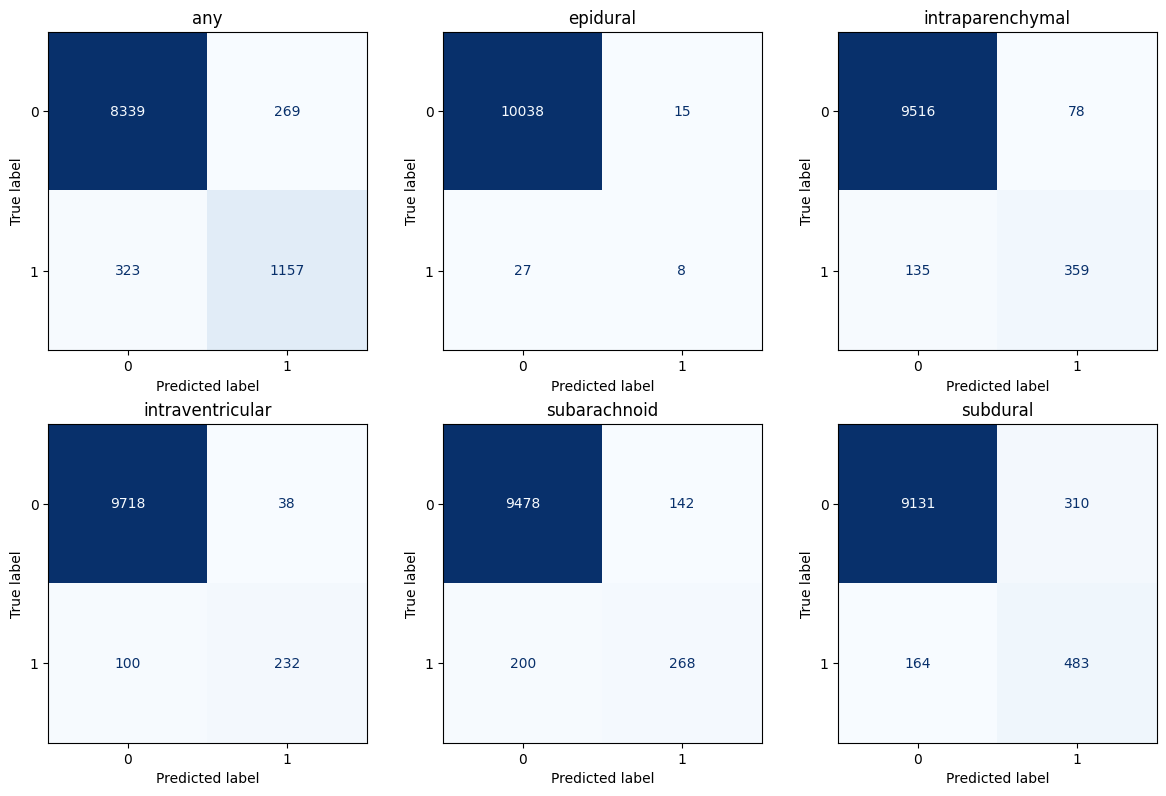

Generating Combined Precision-Recall Curve...


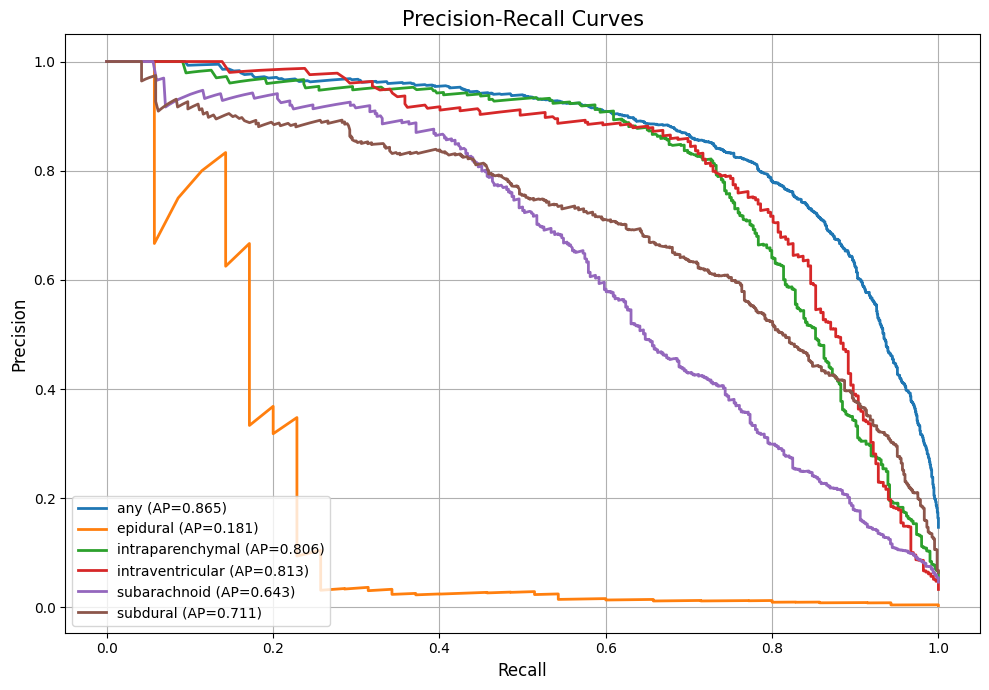

Generating F1-Threshold Curves...


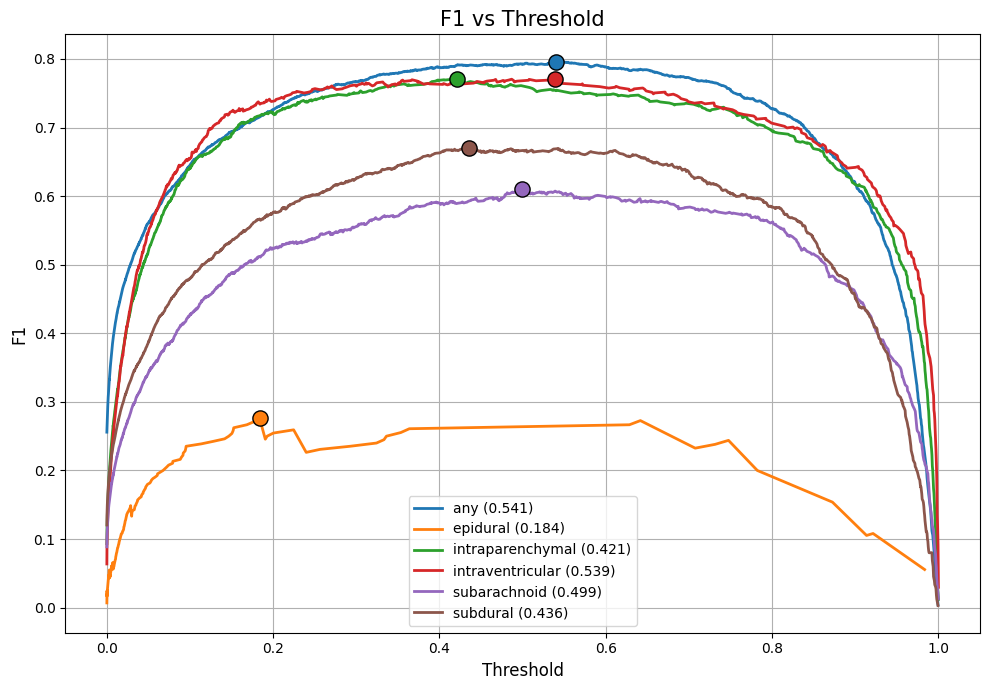


Saved Threshold Summary
              Class  Saved Threshold  F1 at Saved Threshold
0               any         0.540527               0.796284
1          epidural         0.183716               0.275862
2  intraparenchymal         0.421143               0.771214
3  intraventricular         0.538574               0.770764
4      subarachnoid         0.499268               0.610478
5          subdural         0.435791               0.670833

Results saved to: evaluation_results


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


<Figure size 640x480 with 0 Axes>

In [ ]:
%run /kaggle/working/evaluate.py
#ran on val loader


Dataset Summary
----------------------------
Train : 79845
Val   : 10088
Test  : 10069

Sampler class weights
any                 : 2.46
epidural            : 10.00
intraparenchymal    : 4.49
intraventricular    : 5.27
subarachnoid        : 4.53
subdural            : 3.90

Sample weight range: 1.00 - 10.00
Mean sample weight : 1.52

Loaded model.
Saved Validation Macro F1 : 0.6492391969566081

Loaded Thresholds
any                 : 0.541
epidural            : 0.184
intraparenchymal    : 0.421
intraventricular    : 0.539
subarachnoid        : 0.499
subdural            : 0.436


100%|██████████| 630/630 [00:49<00:00, 12.63it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Loss : 0.037038283602297335

Classification Report

                  precision    recall  f1-score   support

             any     0.8470    0.7790    0.8115      1570
        epidural     0.2963    0.2051    0.2424        39
intraparenchymal     0.8440    0.6787    0.7524       526
intraventricular     0.8562    0.7005    0.7706       374
    subarachnoid     0.6813    0.6011    0.6387       569
        subdural     0.5941    0.6715    0.6304       691

       micro avg     0.7626    0.7047    0.7325      3769
       macro avg     0.6865    0.6060    0.6410      3769
    weighted avg     0.7704    0.7047    0.7340      3769
     samples avg     0.1145    0.1087    0.1094      3769


PR-AUC
              Class    PR_AUC
0               any  0.882923
1          epidural  0.146272
2  intraparenchymal  0.804999
3  intraventricular  0.826718
4      subarachnoid  0.700845
5          subdural  0.699014

Thresholds
              Class  Threshold
0               any   0.540527
1          epi

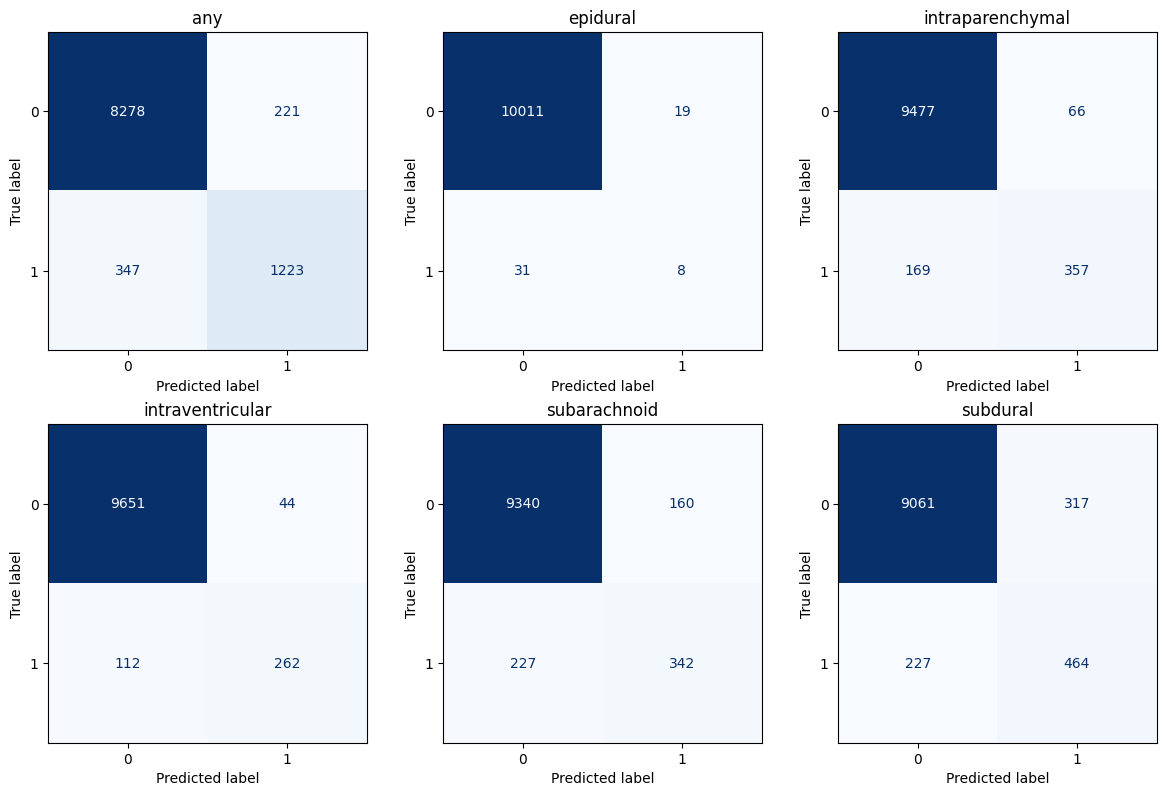

Generating Combined Precision-Recall Curve...


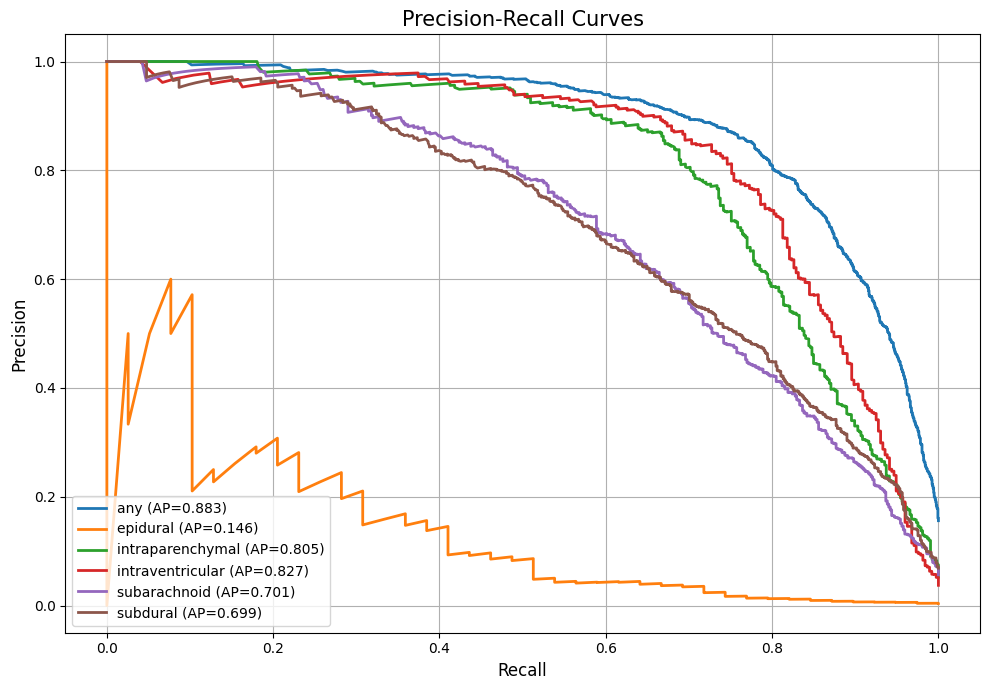

Generating F1-Threshold Curves...


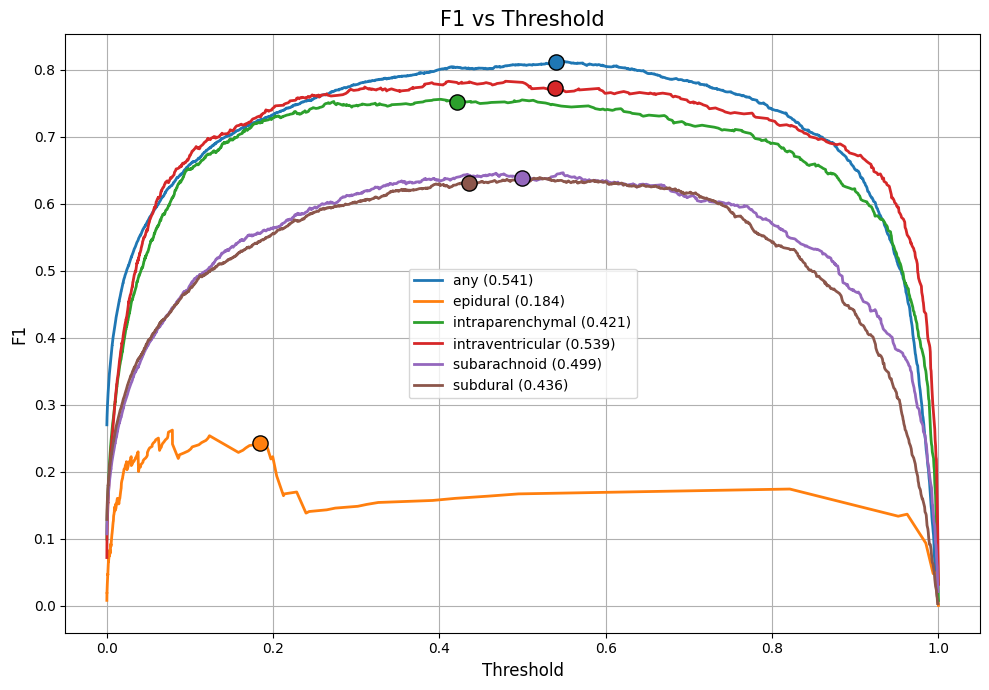


Saved Threshold Summary
              Class  Saved Threshold  F1 at Saved Threshold
0               any         0.540527               0.811277
1          epidural         0.183716               0.242424
2  intraparenchymal         0.421143               0.752371
3  intraventricular         0.538574               0.772394
4      subarachnoid         0.499268               0.638655
5          subdural         0.435791               0.630435

Results saved to: evaluation_results


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


<Figure size 640x480 with 0 Axes>

In [ ]:
%run /kaggle/working/evaluate.py
#ran on test loader

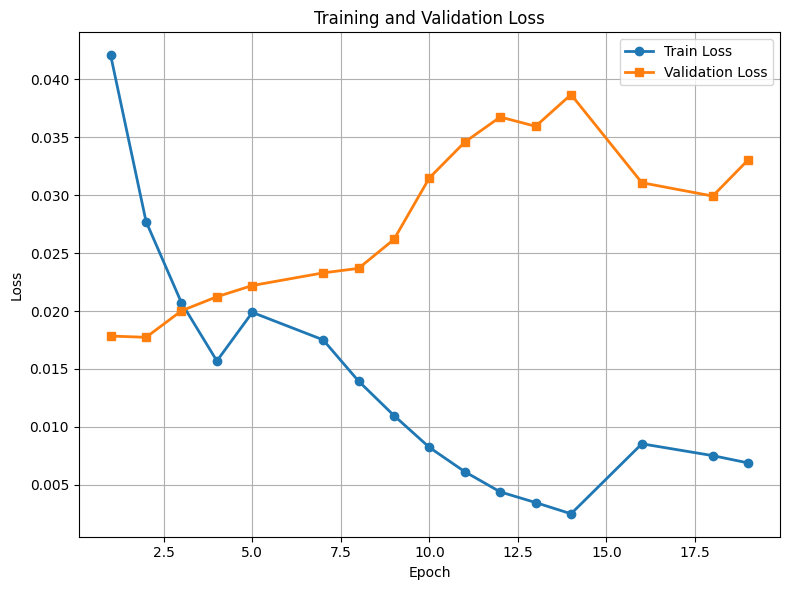

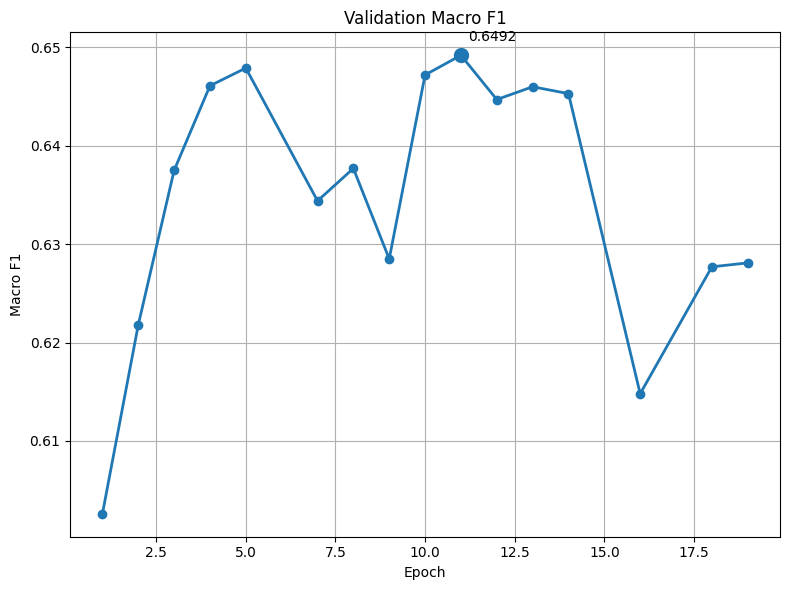

In [38]:
epochs = [1,2,3,4,5,7,8,9,10,11,12,13,14,16,18,19]

train_loss = [
    0.04207,
    0.02772,
    0.02071,
    0.01569,
    0.01988,
    0.01751,
    0.01395,
    0.01098,
    0.00823,
    0.00613,
    0.00439,
    0.00347,
    0.00250,
    0.00854,
    0.00752,
    0.00689,
]

val_loss = [
    0.01784,
    0.01773,
    0.02002,
    0.02123,
    0.02220,
    0.02329,
    0.02368,
    0.02618,
    0.03149,
    0.03458,
    0.03674,
    0.03594,
    0.03868,
    0.03107,
    0.02992,
    0.03304,
]

macro_f1 = [
    0.6026,
    0.6218,
    0.6375,
    0.6461,
    0.6479,
    0.6344,
    0.6377,
    0.6285,
    0.6472,
    0.6492,
    0.6447,
    0.6460,
    0.6453,
    0.6148,
    0.6277,
    0.6281,
]
TRAINING_DIR = os.path.join(OUTPUT_DIR, "training_curves")
os.makedirs(TRAINING_DIR, exist_ok=True)

epochs = [1,2,3,4,5,7,8,9,10,11,12,13,14,16,18,19]

train_loss = [
0.04207,0.02772,0.02071,0.01569,
0.01988,0.01751,0.01395,0.01098,
0.00823,0.00613,0.00439,0.00347,
0.00250,0.00854,0.00752,0.00689
]

val_loss = [
0.01784,0.01773,0.02002,0.02123,
0.02220,0.02329,0.02368,0.02618,
0.03149,0.03458,0.03674,0.03594,
0.03868,0.03107,0.02992,0.03304
]

macro_f1 = [
0.6026,0.6218,0.6375,0.6461,
0.6479,0.6344,0.6377,0.6285,
0.6472,0.6492,0.6447,0.6460,
0.6453,0.6148,0.6277,0.6281
]

# ---------------- Loss ----------------

plt.figure(figsize=(8,6))

plt.plot(
    epochs,
    train_loss,
    marker='o',
    linewidth=2,
    label="Train Loss",
)

plt.plot(
    epochs,
    val_loss,
    marker='s',
    linewidth=2,
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        TRAINING_DIR,
        "loss_curve.png",
    ),
    dpi=300,
)

plt.show()
plt.close()

# ---------------- Macro F1 ----------------

plt.figure(figsize=(8,6))

plt.plot(
    epochs,
    macro_f1,
    marker='o',
    linewidth=2,
)

best_epoch = epochs[np.argmax(macro_f1)]
best_f1 = max(macro_f1)

plt.scatter(
    best_epoch,
    best_f1,
    s=100,
)

plt.annotate(
    f"{best_f1:.4f}",
    (best_epoch, best_f1),
    xytext=(5,10),
    textcoords="offset points",
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Validation Macro F1")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        TRAINING_DIR,
        "macro_f1_curve.png",
    ),
    dpi=300,
)

plt.show()
plt.close()